# Disaster Recovery Cost Prediction and Resilience Optimization
## Week 2 Day 2 — Feature Analysis

## Goal of this notebook

The purpose of this notebook is to assess the quality and usefulness of the engineered features created in the processed disaster-level dataset.

This analysis focuses on:
- understanding feature distributions
- checking relationships between features and the target
- evaluating categorical feature balance
- confirming business-rule features such as `high_cost_incident`
- identifying remaining outliers that may affect modelling

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")

DATA_PATH = Path("../data/processed/processed_disasters.csv")

## Section B — Load the Processed Dataset

This dataset was created in the feature engineering stage and contains disaster-level records, the modelling target, and engineered predictors.

In [3]:
df = pd.read_csv(DATA_PATH)

print("Processed dataset shape:", df.shape)
print("\nColumns:")
for col in df.columns:
    print("-", col)

Processed dataset shape: (69770, 43)

Columns:
- disasterNumber
- state
- incidentType
- declarationType
- declarationDate
- incidentBeginDate
- incidentEndDate
- declaration_year
- declaration_month
- incident_duration_days
- season
- census_region
- state_5yr_disaster_count
- high_cost_incident
- project_count
- avg_project_amount
- total_obligated_amount
- log_total_obligated_amount
- femaDeclarationString
- fyDeclared
- declarationTitle
- ihProgramDeclared
- iaProgramDeclared
- paProgramDeclared
- hmProgramDeclared
- disasterCloseoutDate
- tribalRequest
- fipsStateCode
- fipsCountyCode
- placeCode
- designatedArea
- declarationRequestNumber
- lastIAFilingDate
- incidentId
- region
- designatedIncidentTypes
- lastRefresh
- hash
- id
- totalObligatedAmountPa
- totalObligatedAmountCatAb
- totalObligatedAmountCatC2g
- totalObligatedAmountHmgp


In [4]:
display(df.head())

,disasterNumber,state,incidentType,declarationType,declarationDate,incidentBeginDate,incidentEndDate,declaration_year,declaration_month,incident_duration_days,season,census_region,state_5yr_disaster_count,high_cost_incident,project_count,avg_project_amount,total_obligated_amount,log_total_obligated_amount,femaDeclarationString,fyDeclared,declarationTitle,ihProgramDeclared,iaProgramDeclared,paProgramDeclared,hmProgramDeclared,disasterCloseoutDate,tribalRequest,fipsStateCode,fipsCountyCode,placeCode,designatedArea,declarationRequestNumber,lastIAFilingDate,incidentId,region,designatedIncidentTypes,lastRefresh,hash,id,totalObligatedAmountPa,totalObligatedAmountCatAb,totalObligatedAmountCatC2g,totalObligatedAmountHmgp
0,5529,OR,Fire,FM,2024-08-09 00:00:00+00:00,2024-08-08 00:00:00+00:00,NaN,2024,8,0.0,Summer,West,189,False,0.0,0.000000,0.00,0.000000,FM-5529-OR,2024,LEE FALLS FIRE,False,False,True,True,NaN,False,41,67,99067,Washington (County),24122,NaN,2024081001,10,R,2024-08-27T18:22:14.800Z,ae87cf3c6ed795015b714af7166c7c295b2b67c7,09e3f81a-5e16-4b72-b317-1c64e0cfa59c,NaN,NaN,NaN,0.00
1,5528,OR,Fire,FM,2024-08-06 00:00:00+00:00,2024-08-04 00:00:00+00:00,NaN,2024,8,0.0,Summer,West,189,False,0.0,0.000000,0.00,0.000000,FM-5528-OR,2024,ELK LANE FIRE,False,False,True,True,NaN,False,41,31,99031,Jefferson (County),24116,NaN,2024080701,10,R,2024-08-27T18:22:14.800Z,432cf0995c47e3895cea696ede5621b810460501,59983f89-30bf-4888-b21b-62e8d57d9aac,NaN,NaN,NaN,0.00
2,5527,OR,Fire,FM,2024-08-02 00:00:00+00:00,2024-08-02 00:00:00+00:00,NaN,2024,8,0.0,Summer,West,189,False,0.0,0.000000,0.00,0.000000,FM-5527-OR,2024,MILE MARKER 132 FIRE,False,False,True,True,NaN,False,41,17,99017,Deschutes (County),24111,NaN,2024080301,10,R,2024-08-27T18:22:14.800Z,2f21d90cb6bc64b0d4121aa3f18d852bbb4b11fa,8d13ecf0-bc2f-496b-8c9f-b2e73da832a0,NaN,NaN,NaN,0.00
3,4312,CA,Severe Storm,DR,2017-05-02 00:00:00+00:00,2017-02-08 00:00:00+00:00,2017-02-11 00:00:00+00:00,2017,5,3.0,Spring,West,206,True,2.0,149963.760000,269934.77,12.505939,DR-4312-CA,2017,FLOODING,False,False,True,True,2025-03-25T00:00:00.000Z,True,6,0,60347,Resighini Rancheria (Indian Reservation),17035,NaN,2017041001,9,NaN,2025-03-26T20:21:32.579Z,432a3a64bdbb291ae26cf5a27a33deeabb380481,98a7c5bb-2346-45aa-a1ca-0399440d4f0b,269934.77,36627.59,233307.18,1650.00
4,4251,AL,Severe Storm,DR,2016-01-21 00:00:00+00:00,2015-12-23 00:00:00+00:00,2015-12-31 00:00:00+00:00,2016,1,8.0,Winter,South,71,True,693.0,68969.713853,36201886.01,17.404622,DR-4251-AL,2016,"SEVERE STORMS, TORNADOES, STRAIGHT-LINE WINDS,...",False,False,True,True,2025-03-27T00:00:00.000Z,False,1,1,99001,Autauga (County),16003,NaN,2015122301,4,NaN,2025-03-27T12:21:46.559Z,dcd4ce6b37ee49875b3f1e32e9a8a16cd6a803d3,5229bbae-eee6-42b8-b277-edbafa8d6cb2,36201886.24,1834108.21,32944324.61,5530482.83


## Section C — Basic Quality Checks on Engineered Features

Before analyzing feature relationships, it is important to confirm that the engineered columns exist, have the expected structure, and do not contain unexpected null values.

In [5]:
engineered_cols = [
    "declaration_year",
    "declaration_month",
    "incident_duration_days",
    "season",
    "census_region",
    "state_5yr_disaster_count",
    "high_cost_incident",
    "project_count",
    "avg_project_amount",
    "total_obligated_amount",
    "log_total_obligated_amount"
]

existing_engineered_cols = [col for col in engineered_cols if col in df.columns]

quality_check = pd.DataFrame({
    "column": existing_engineered_cols,
    "dtype": [df[col].dtype for col in existing_engineered_cols],
    "null_count": [df[col].isna().sum() for col in existing_engineered_cols],
    "null_rate_pct": [round(df[col].isna().mean() * 100, 2) for col in existing_engineered_cols],
    "n_unique": [df[col].nunique(dropna=True) for col in existing_engineered_cols]
})

display(quality_check)

,column,dtype,null_count,null_rate_pct,n_unique
0,declaration_year,int64,0,0.0,74
1,declaration_month,int64,0,0.0,12
2,incident_duration_days,float64,0,0.0,150
3,season,object,0,0.0,4
4,census_region,object,0,0.0,6
5,state_5yr_disaster_count,int64,0,0.0,472
6,high_cost_incident,bool,0,0.0,2
7,project_count,float64,0,0.0,760
8,avg_project_amount,float64,0,0.0,1767
9,total_obligated_amount,float64,0,0.0,1767


## Section D — Distribution of Engineered Numeric Features

This section checks how the main numeric engineered features are distributed. This helps identify skewness, sparse values, concentration near zero, or unusual patterns that may affect modelling.

In [6]:
numeric_features = [
    "declaration_year",
    "declaration_month",
    "incident_duration_days",
    "state_5yr_disaster_count",
    "project_count",
    "avg_project_amount",
    "total_obligated_amount",
    "log_total_obligated_amount"
]

numeric_features = [col for col in numeric_features if col in df.columns]
numeric_features

['declaration_year',
 'declaration_month',
 'incident_duration_days',
 'state_5yr_disaster_count',
 'project_count',
 'avg_project_amount',
 'total_obligated_amount',
 'log_total_obligated_amount']

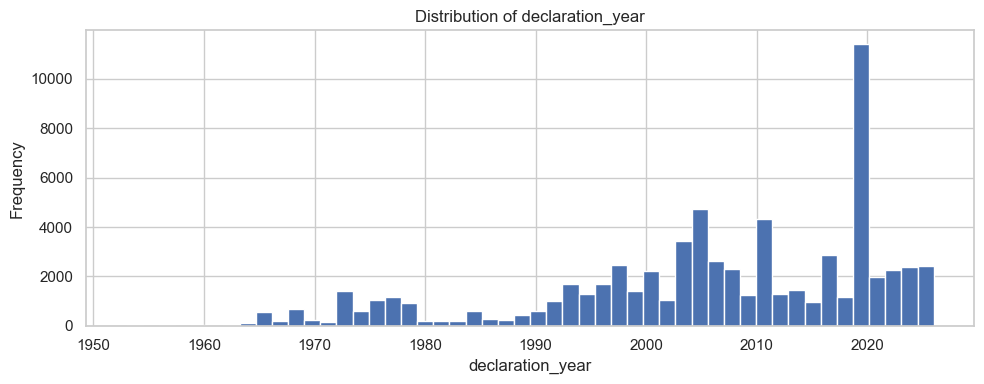

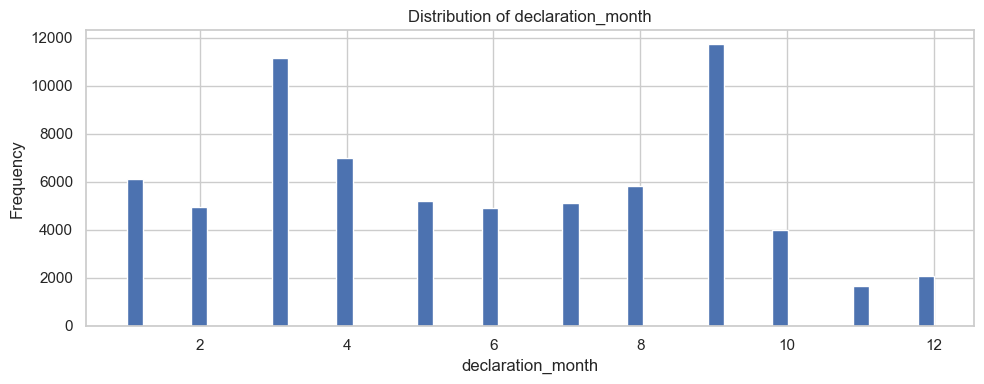

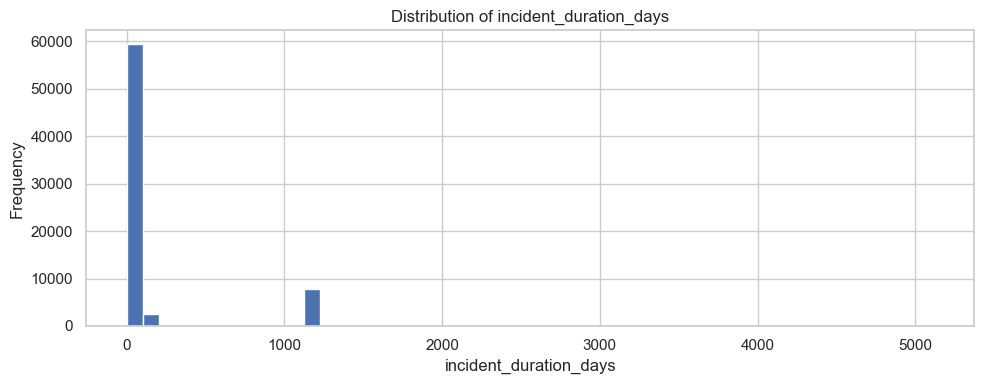

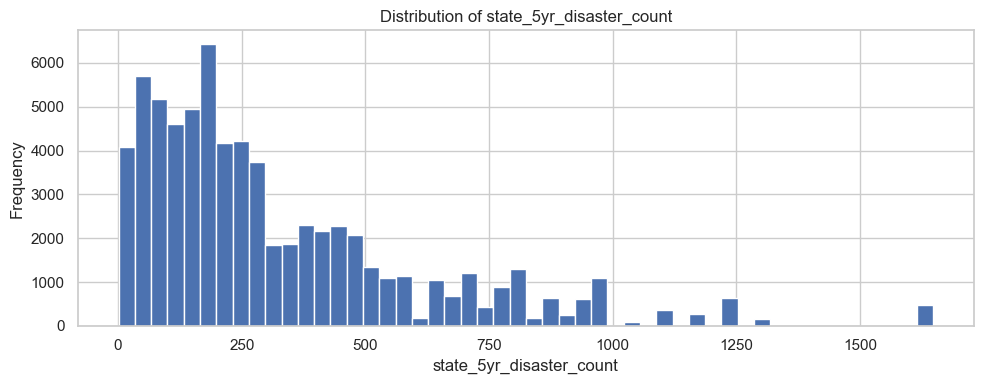

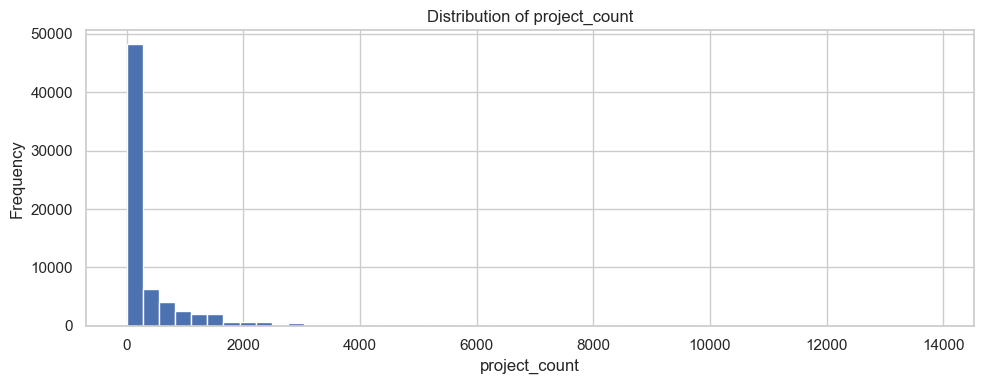

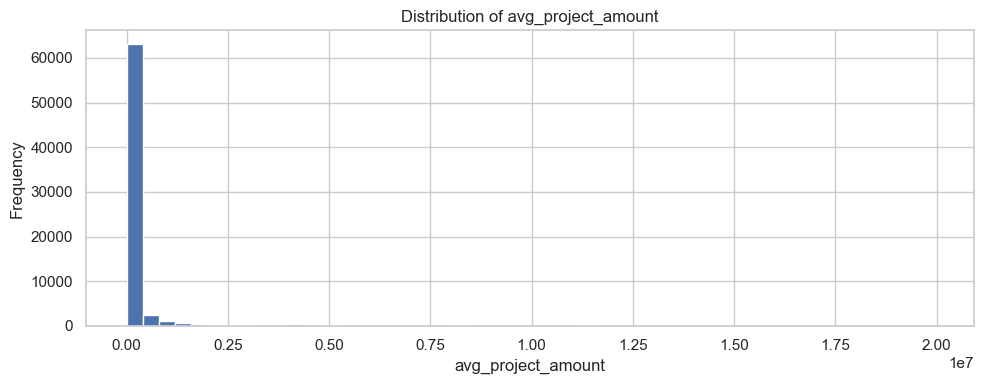

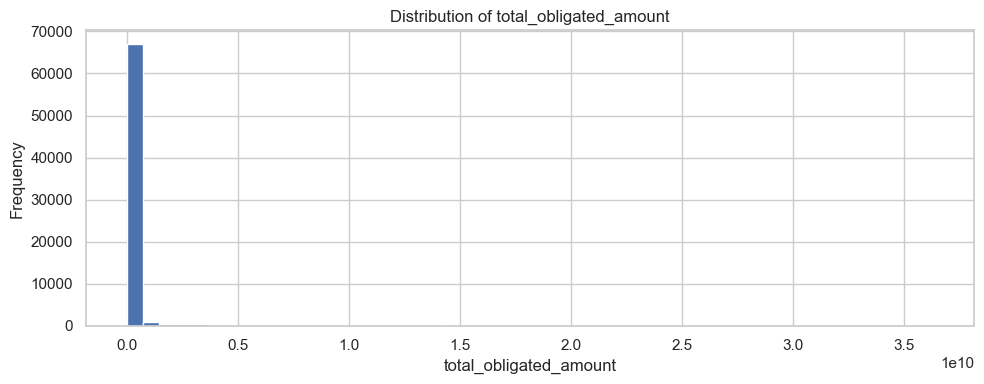

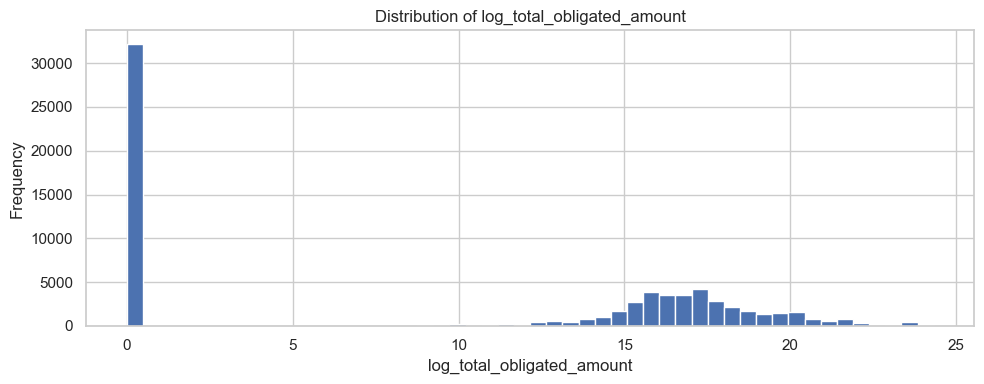

In [7]:
for col in numeric_features:
    plt.figure(figsize=(10, 4))
    plt.hist(df[col].dropna(), bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

### Findings

The distributions of the engineered numeric features reveal several important characteristics of the dataset:

**1. Highly skewed features**
- `total_obligated_amount`, `project_count`, and `avg_project_amount` are **heavily right-skewed**, with a large concentration of low values and a long tail of extreme high values.
- `incident_duration_days` also shows strong skewness, with most incidents having very short durations and a few extreme cases extending beyond 1000 days.
- `state_5yr_disaster_count` is moderately right-skewed, indicating that while most states experience a relatively low number of disasters, a few states have significantly higher historical counts.

**2. Approximately well-distributed features**
- `declaration_year` shows a gradual increase in frequency over time, reflecting increased disaster reporting or occurrence in recent years.
- `declaration_month` appears reasonably balanced across months, although some months (e.g., late summer/early autumn) show higher frequencies, likely due to seasonal disaster patterns.

**3. Features with many zero or near-zero values**
- `project_count` and `total_obligated_amount` contain a large number of zero or near-zero values, indicating that many disasters either did not receive funding or had minimal financial impact.
- This suggests a **zero-inflated distribution**, which may influence model choice and performance.

**4. Effectiveness of transformation**
- The `log_total_obligated_amount` feature significantly reduces skewness compared to the raw target, producing a more spread-out and approximately normal distribution.
- This transformation is appropriate and will improve model stability and performance.

**5. Outliers and extreme values**
- Several features contain extreme outliers, particularly:
  - `total_obligated_amount`
  - `avg_project_amount`
  - `project_count`
- These values likely represent major disaster events and are **business-relevant rather than data errors**, so they should be retained but may require careful handling during modelling.

**6. Implications for modelling**
- Highly skewed features may benefit from:
  - log transformations (already applied to the target)
  - potential scaling or capping during modelling
- Zero-heavy features may require models that handle sparse or zero-inflated data effectively.
- Outliers should be preserved but monitored, as they can strongly influence model predictions.

Overall, the engineered features show meaningful variation and structure, but several require careful handling due to skewness, sparsity, and extreme values.

## Section E — Distribution of Engineered Categorical Features

This section checks the class balance of key categorical features. This helps reveal whether some categories are too rare, overly dominant, or potentially unstable for modelling.

In [8]:
categorical_features = [
    "season",
    "census_region",
    "high_cost_incident",
    "incidentType",
    "declarationType"
]

categorical_features = [col for col in categorical_features if col in df.columns]
categorical_features

['season',
 'census_region',
 'high_cost_incident',
 'incidentType',
 'declarationType']

In [9]:
for col in categorical_features:
    print(f"\nValue counts for {col}:")
    display(df[col].value_counts(dropna=False).to_frame("count"))


Value counts for season:


,count
season,
Spring,23347
Autumn,17402
Summer,15881
Winter,13140



Value counts for census_region:


,count
census_region,
South,35555
Midwest,18667
West,7077
Northeast,6009
Territory,2377
Unknown,85



Value counts for high_cost_incident:


,count
high_cost_incident,
True,45877
False,23893



Value counts for incidentType:


,count
incidentType,
Severe Storm,19299
Hurricane,13721
Flood,11234
Biological,7857
Fire,3864
Snowstorm,3707
Severe Ice Storm,2956
Tornado,1623
Winter Storm,1349



Value counts for declarationType:


,count
declarationType,
DR,46221
EM,21458
FM,2091


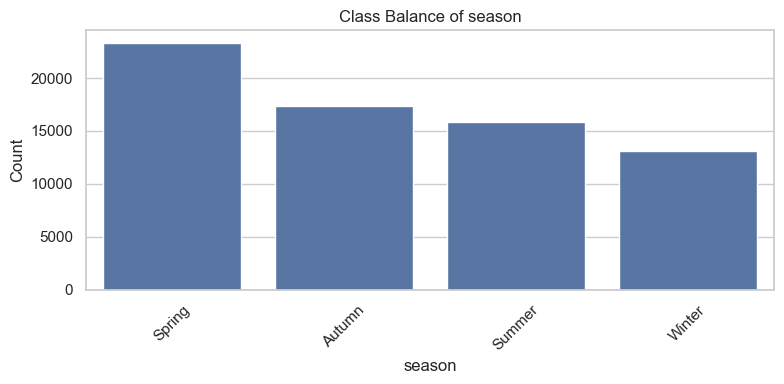

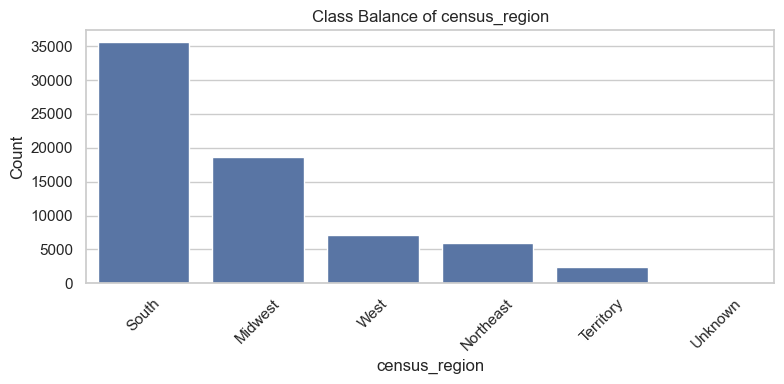

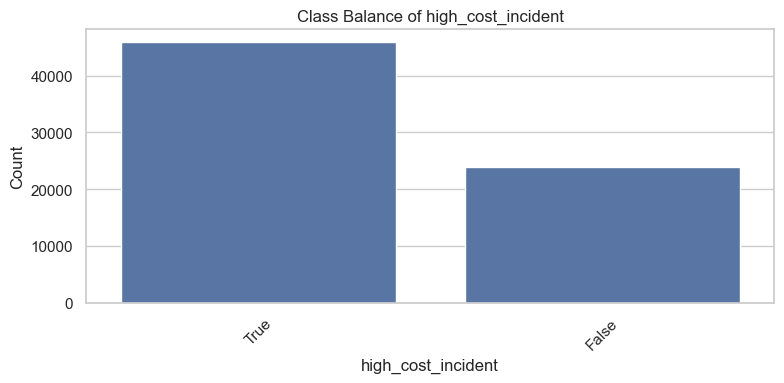

In [10]:
for col in ["season", "census_region", "high_cost_incident"]:
    if col in df.columns:
        plt.figure(figsize=(8, 4))
        sns.countplot(data=df, x=col, order=df[col].value_counts().index)
        plt.title(f"Class Balance of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

### Findings

The categorical feature distributions show varying levels of class balance:

**1. Season**
- The `season` feature is relatively well distributed across all categories.
- Spring has the highest frequency, followed by Autumn and Summer, while Winter has slightly fewer observations.
- This suggests that seasonal variation is present and likely meaningful for modelling.

**2. Census Region**
- The `South` region dominates the dataset, with significantly more disasters than other regions.
- The `Midwest` is the second most frequent, followed by `West` and `Northeast`.
- `Territory` and `Unknown` categories are relatively small.
- This imbalance reflects real-world geographic exposure but may require careful handling to avoid regional bias in modelling.

**3. High Cost Incident Flag**
- The dataset is moderately imbalanced, with more `True` values than `False`.
- This indicates that a large proportion of disasters fall into high-cost categories.
- The feature remains useful but may not be highly discriminative on its own.

Overall, categorical features show meaningful variation, though some imbalance (particularly by region) should be considered during modelling.

## Section F — Numeric Feature vs Target Relationships

This section checks whether numeric engineered features show visible relationships with the target variable.

Because the raw target is highly skewed, the log-transformed target is used for clearer interpretation.

In [11]:
target_col = "log_total_obligated_amount"

scatter_features = [
    "incident_duration_days",
    "state_5yr_disaster_count",
    "project_count",
    "avg_project_amount",
    "declaration_year"
]

scatter_features = [col for col in scatter_features if col in df.columns]
scatter_features

['incident_duration_days',
 'state_5yr_disaster_count',
 'project_count',
 'avg_project_amount',
 'declaration_year']

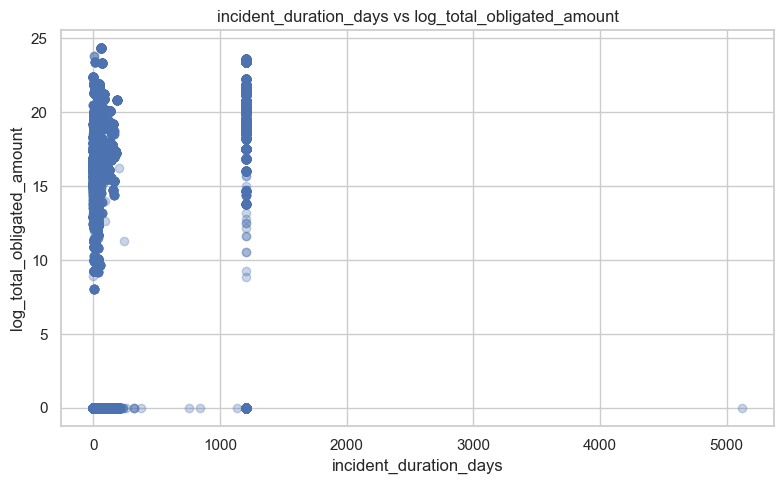

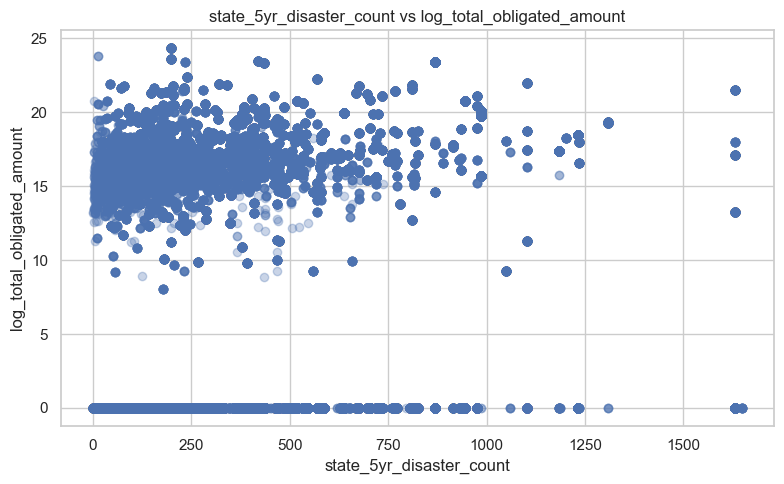

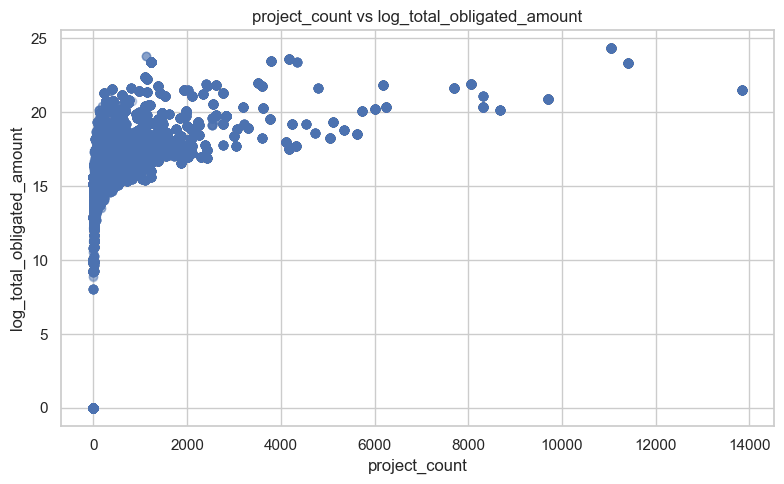

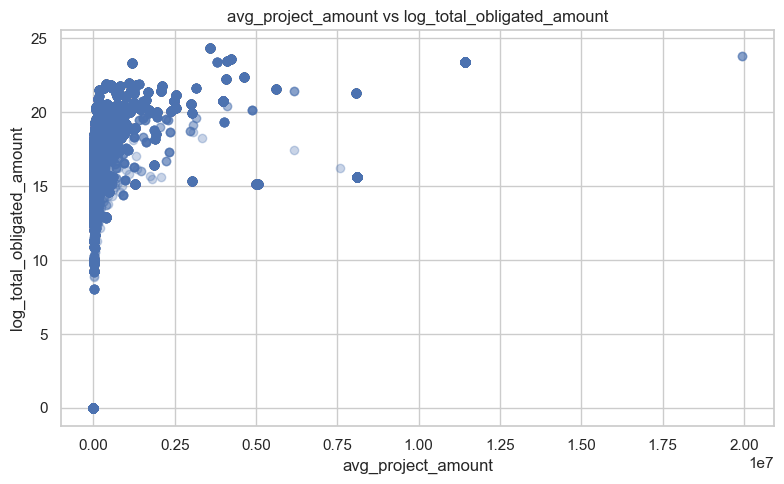

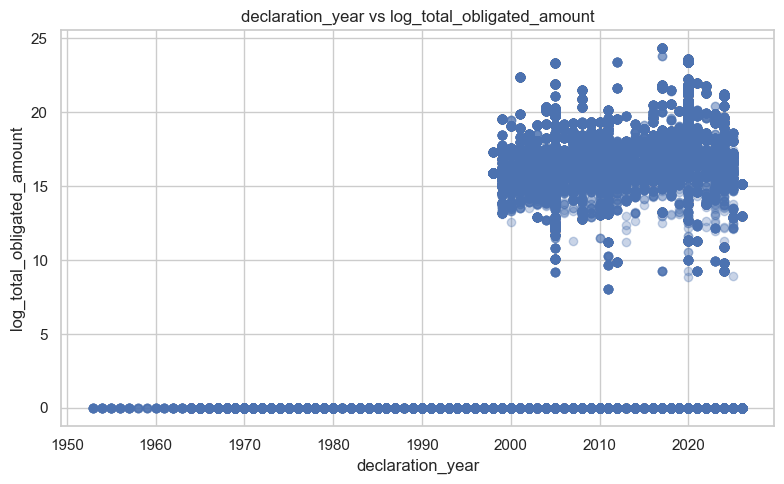

In [12]:
for col in scatter_features:
    plt.figure(figsize=(8, 5))
    plt.scatter(df[col], df[target_col], alpha=0.3)
    plt.title(f"{col} vs {target_col}")
    plt.xlabel(col)
    plt.ylabel(target_col)
    plt.tight_layout()
    plt.show()

### Findings

The scatter plots reveal several important relationships between engineered features and the target variable:

**1. Project Count**
- `project_count` shows the **strongest positive relationship** with the target.
- As the number of projects increases, the total obligated amount increases significantly.
- This is expected, as more projects directly contribute to higher recovery costs.
- This feature is likely to be one of the most important predictors in the model.

**2. Average Project Amount**
- `avg_project_amount` shows a **moderate positive relationship** with the target.
- Higher average project costs tend to correspond to higher total costs, though the relationship is more dispersed.
- This suggests it contributes useful but less dominant predictive power compared to project count.

**3. State 5-Year Disaster Count**
- `state_5yr_disaster_count` shows a **weak to moderate relationship** with the target.
- States with higher historical disaster frequency tend to have slightly higher costs, but the relationship is not strong.
- This feature may capture underlying risk exposure but is not a primary driver of cost.

**4. Incident Duration**
- `incident_duration_days` shows **no clear linear relationship** with the target.
- Most disasters have short durations, and extreme duration values do not consistently correspond to higher costs.
- This feature may still be useful in non-linear models but is not strongly predictive on its own.

**5. Declaration Year**
- `declaration_year` shows **no strong relationship** with the target.
- Costs appear relatively stable over time, with no clear upward or downward trend in the log-transformed target.
- This suggests temporal trends may not be a major driver of cost, or may require more complex time-based features.

**6. Zero-value observations**
- A clear horizontal line at zero indicates many disasters with no funding.
- This reinforces the presence of **zero-inflation** in the dataset, which may influence modelling strategy.

Overall, `project_count` and `avg_project_amount` emerge as the most informative numeric features, while others provide supporting context.

## Section G — Target Distribution by Key Categorical Features

This section compares the target variable across important categorical groups:
- region
- season
- incident type

Boxplots are useful here because they show median, spread, and outliers across groups.

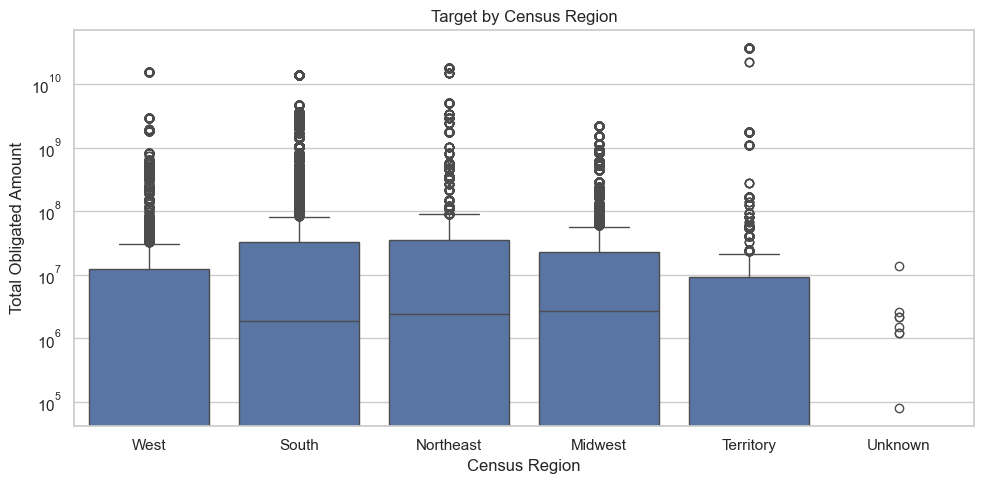

In [13]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="census_region", y="total_obligated_amount")
plt.yscale("log")
plt.title("Target by Census Region")
plt.xlabel("Census Region")
plt.ylabel("Total Obligated Amount")
plt.tight_layout()
plt.show()

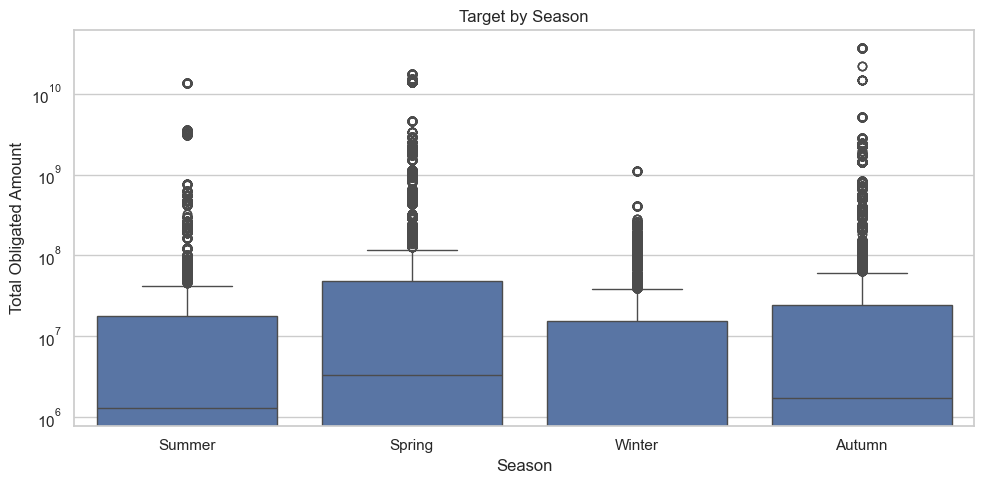

In [14]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="season", y="total_obligated_amount")
plt.yscale("log")
plt.title("Target by Season")
plt.xlabel("Season")
plt.ylabel("Total Obligated Amount")
plt.tight_layout()
plt.show()

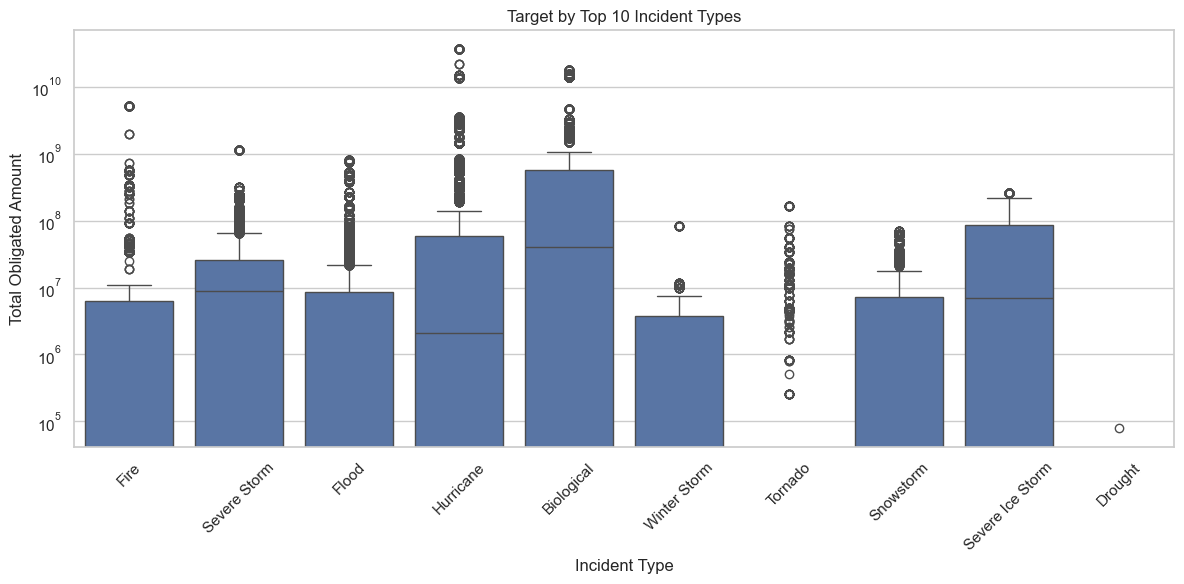

In [15]:
top_incidents = df["incidentType"].value_counts().head(10).index
df_top_incidents = df[df["incidentType"].isin(top_incidents)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top_incidents, x="incidentType", y="total_obligated_amount")
plt.yscale("log")
plt.title("Target by Top 10 Incident Types")
plt.xlabel("Incident Type")
plt.ylabel("Total Obligated Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Findings

The boxplots provide insights into how the target variable varies across key categorical features:

**1. Census Region**
- The `South` and `Northeast` regions show higher median costs and wider variability.
- The `West` and `Midwest` regions have slightly lower medians but still exhibit significant spread.
- `Territory` shows high variability despite a smaller sample size.
- This suggests geographic location plays a meaningful role in disaster cost variation.

**2. Season**
- Spring shows the highest median and widest spread of costs.
- Autumn also exhibits high variability and includes several extreme high-cost disasters.
- Summer and Winter generally have lower medians but still contain high-cost outliers.
- This indicates that seasonality influences disaster severity and financial impact.

**3. Incident Type**
- Incident type is one of the **strongest drivers of cost variation**.
- Hurricanes and Biological incidents show some of the highest median costs and largest spreads.
- Severe storms, floods, and tornadoes also show substantial variability.
- Lower-cost incident types (e.g., drought) appear more stable with fewer extreme values.

Overall, categorical features—especially `incidentType` and `census_region`—are strong candidates for predictive modelling.

## Section H — Confirm the `high_cost_incident` Flag

This section checks whether the `high_cost_incident` feature correctly captures the intended incident types:
- Hurricane
- Flood
- Tornado
- Severe Storm

In [16]:
check_cols = ["incidentType", "high_cost_incident"]
display(df[check_cols].drop_duplicates().sort_values(["high_cost_incident", "incidentType"]))

,incidentType,high_cost_incident
707,Biological,False
23979,Chemical,False
1867,Coastal Storm,False
3727,Dam/Levee Break,False
27040,Drought,False
1127,Earthquake,False
0,Fire,False
34276,Fishing Losses,False
1250,Freezing,False
33284,Human Cause,False


In [17]:
flag_summary = (
    df.groupby(["incidentType", "high_cost_incident"])
    .size()
    .reset_index(name="count")
    .sort_values(["high_cost_incident", "count"], ascending=[False, False])
)

display(flag_summary)

,incidentType,high_cost_incident,count
15,Severe Storm,True,19299
11,Hurricane,True,13721
8,Flood,True,11234
19,Tornado,True,1623
0,Biological,False,7857
6,Fire,False,3864
16,Snowstorm,False,3707
14,Severe Ice Storm,False,2956
26,Winter Storm,False,1349
4,Drought,False,1292


In [18]:
expected_flagged = {"Hurricane", "Flood", "Tornado", "Severe Storm"}

actual_flagged = set(df.loc[df["high_cost_incident"] == True, "incidentType"].dropna().unique())

print("Expected flagged incidents:", expected_flagged)
print("Actual flagged incidents:", actual_flagged)
print("Missing from flagged set:", expected_flagged - actual_flagged)
print("Unexpected flagged incidents:", actual_flagged - expected_flagged)

Expected flagged incidents: {'Flood', 'Tornado', 'Hurricane', 'Severe Storm'}
Actual flagged incidents: {'Flood', 'Tornado', 'Hurricane', 'Severe Storm'}
Missing from flagged set: set()
Unexpected flagged incidents: set()


### Findings

The validation of the `high_cost_incident` feature confirms that it has been correctly implemented based on the intended business logic.

**1. Correct flag assignment**
- The feature correctly flags the following incident types as high-cost:
  - Hurricane
  - Flood
  - Tornado
  - Severe Storm
- All other incident types are correctly marked as `False`.

**2. No missing or unexpected classifications**
- There are no missing expected categories in the flagged set.
- There are no unexpected incident types incorrectly flagged as high-cost.

**3. Distribution of flagged incidents**
- Severe Storm has the highest frequency among high-cost incidents, followed by Hurricane and Flood.
- Tornado appears less frequent but still correctly classified.

**4. Interpretation**
- The feature aligns well with domain knowledge, as these incident types are typically associated with significant infrastructure damage and recovery costs.
- The relatively high number of `True` values suggests that many disasters fall into these high-impact categories.

Overall, the `high_cost_incident` feature is **accurate, meaningful, and suitable for modelling**, and can serve as a strong categorical predictor.

## Section I — Remaining Outlier Review

This section reviews whether important numeric fields still contain extreme values after feature engineering.

At this stage, the goal is not necessarily to remove outliers, but to document them and decide whether they should be:
- kept as real events
- transformed
- capped later during modelling

In [19]:
outlier_features = [
    "total_obligated_amount",
    "avg_project_amount",
    "project_count",
    "incident_duration_days"
]

outlier_features = [col for col in outlier_features if col in df.columns]

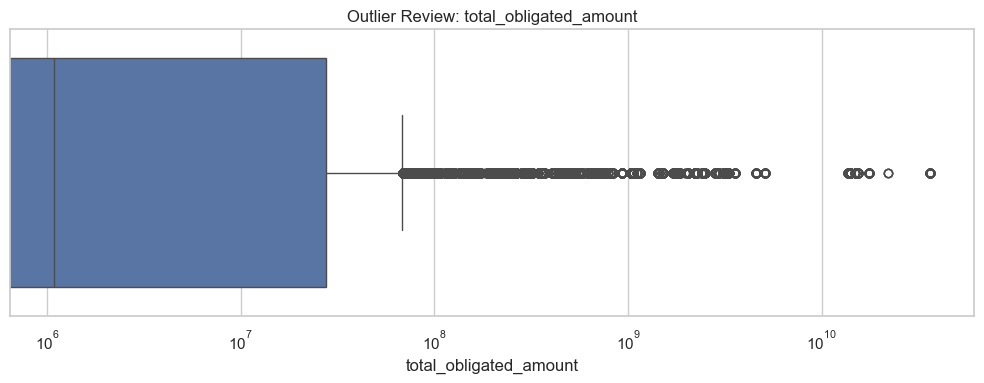

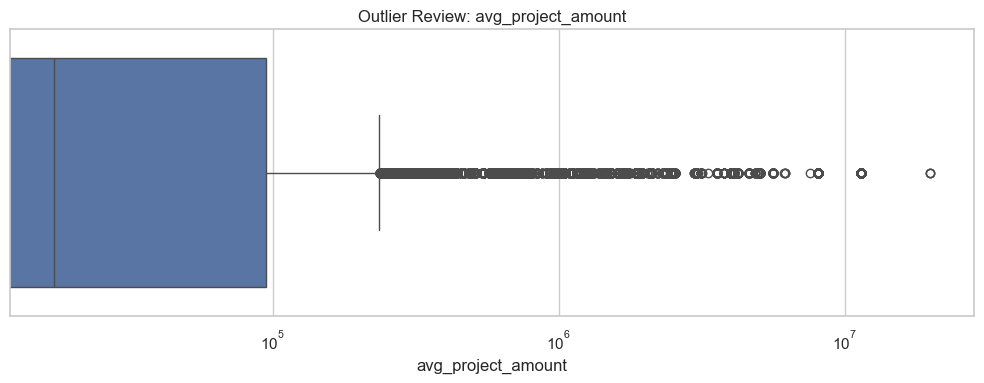

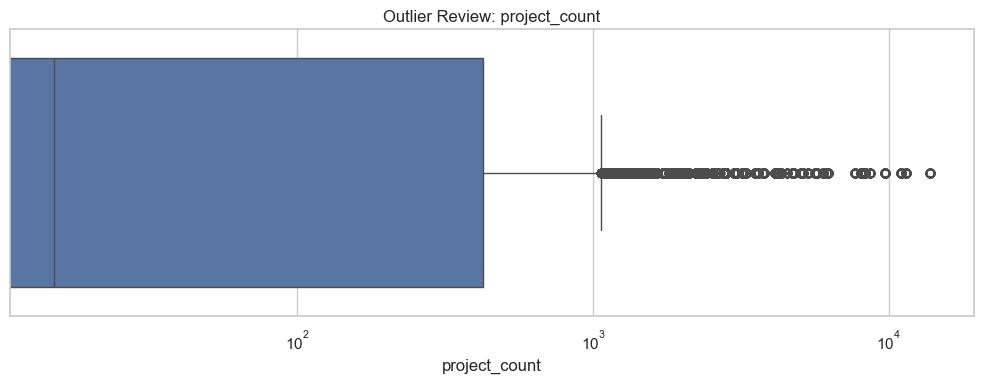

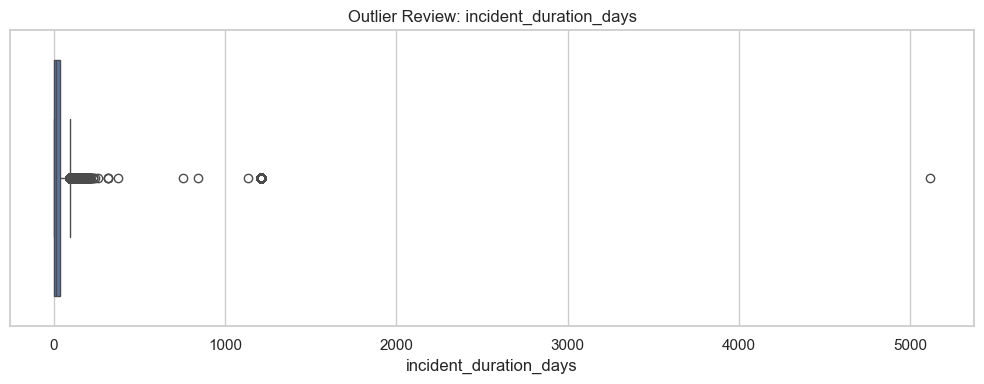

In [20]:
for col in outlier_features:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[col])
    if col in ["total_obligated_amount", "avg_project_amount", "project_count"]:
        plt.xscale("log")
    plt.title(f"Outlier Review: {col}")
    plt.tight_layout()
    plt.show()

In [21]:
summary_stats = df[outlier_features].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T
display(summary_stats)

,count,mean,std,min,1%,5%,50%,95%,99%,max
total_obligated_amount,69770.0,2.430838e+08,1.744860e+09,0.0,0.0,0.0,1.084949e+06,5.787536e+08,3.589060e+09,3.632722e+10
avg_project_amount,69770.0,2.560415e+05,1.034446e+06,0.0,0.0,0.0,1.718888e+04,1.117550e+06,5.000000e+06,1.992927e+07
project_count,69770.0,4.629952e+02,1.155513e+03,0.0,0.0,0.0,1.500000e+01,2.085000e+03,6.004000e+03,1.383600e+04
incident_duration_days,69770.0,1.554559e+02,3.764006e+02,0.0,0.0,0.0,1.300000e+01,1.207000e+03,1.207000e+03,5.117000e+03


### Findings

The outlier analysis of key numeric features highlights the presence of extreme values across multiple variables:

**1. Total Obligated Amount**
- The target variable exhibits extreme right skewness, with values ranging from zero to over tens of billions.
- A significant number of observations are clustered at low values, while a small number of disasters account for extremely large costs.
- These outliers represent major disaster events and are likely to be **genuine and business-critical**, rather than errors.

**2. Average Project Amount**
- `avg_project_amount` shows substantial variability, with a long tail of high values.
- Most projects have relatively low average costs, but a small number of disasters involve extremely expensive projects.
- These values are likely tied to large-scale infrastructure or complex recovery efforts.

**3. Project Count**
- `project_count` is highly skewed, with most disasters involving a small number of projects.
- However, a few disasters have very high project counts (up to several thousand), indicating large-scale recovery operations.

**4. Incident Duration**
- `incident_duration_days` shows extreme outliers, with some incidents lasting several thousand days.
- While most incidents are short-lived, these extreme durations may reflect prolonged recovery periods or data recording inconsistencies.
- These values should be reviewed carefully during modelling.

**5. Statistical summary insights**
- The gap between median and upper percentiles (95th and 99th) is large across all features, confirming heavy skewness.
- The maximum values are significantly higher than typical observations, reinforcing the presence of extreme events.

**6. Modelling implications**
- These outliers are **not errors** but represent the most impactful disasters, which are central to the problem being solved.
- Therefore:
  - They should **not be removed**
  - They may require transformation (e.g., log scaling — already applied to target)
  - They should be carefully handled to avoid model instability

Overall, the dataset contains **meaningful extreme values** that reflect real-world disaster severity and should be preserved for modelling.

## Day 2 Conclusion

Today’s feature analysis confirmed that the engineered variables have meaningful structure and are suitable for modelling. Numeric features were inspected for skewness and spread, categorical features were reviewed for class balance, and relationships with the target variable were explored through scatter plots and boxplots.

The analysis also verified that the `high_cost_incident` flag behaves as intended and highlighted remaining outliers that are likely to represent genuine high-impact disaster events rather than data errors. These findings provide a strong basis for informed feature selection and model training in the next stage.